In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import math
from scipy.stats import chi2_contingency
import xgboost as xgb



### Instructed Steps for the Project
1. Load the dataset.
2. Explore the data to understand its structure — features, target variable, shape, and data types.
3. Clean the dataset (handle duplicates, missing values, etc.).
4. Split the dataset into features (X) and target (y).
5. Explore correlations between the target and features, and among features. Include your interpretations.
6. Handle categorical variables (encoding).
7. Train baseline models such as Linear Regression and KNN Regressor.
8. Evaluate the models using metrics like R² and MAE.
9. Improve your models:
    - Data side: handle outliers, multicollinearity, feature selection, normalization/standardization, feature engineering, etc.
    - Model side: try other models (especially ensemble methods) and perform hyperparameter tuning.
10. Compare all models and select the best one.
11. Identify which features most strongly influence house prices based on your best model.

Deliverables:
- A Jupyter Notebook containing all analysis, code, and results.
- A Presentation (10 minutes) summarizing your ML process, insights, and final model.
- A README file explaining your workflow, reasoning, and key decisions.

In [2]:
pd.set_option('display.max_columns', None)

In [3]:
df = pd.read_csv('/Users/manish/Documents/Ironhack/Week 5/Ironkaggle/king_ country_ houses_aa.csv')
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

In [5]:
data = df.copy()
data.head()
data.drop_duplicates(inplace=True)
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

## Our data set has 21 columns and 21613 rows. There is no missing value in any of the columns, the data types in each column are int or float except date column where the data type is string. We observe that the entris in the date column has tail T000000, so we first drop the tail and convert the data type to int.

In [7]:

for date in data['date']:
    data['date']=date.replace('T000000', '')
data.info()
data.head()

    
  

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141015,221900.0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141015,538000.0,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20141015,180000.0,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141015,604000.0,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20141015,510000.0,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


In [8]:
data['date'] = data['date'].astype(int)
data.info()
data = data.drop('id', axis = 1)
data.drop_duplicates(inplace=True)
data.shape

<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  int64  
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long           21

(21608, 20)

We see that the same property has been priced differently as well, although such a number is very small.

## Our target vaiable is price and there are no missing values so we cretae two data frame X and y where y is the target data frame and X is the feature data frame.

In [9]:
X = data.drop(['price'], axis = 1)
y = data['price']
X.head()
X.shape

(21608, 19)

## Now we move to analyze the features seperately from the X

In [10]:
bedrooms_count = X['bedrooms'].value_counts()
bathroom_count= X['bathrooms'].value_counts()
#bedrooms_count,
#sns.barplot(bathroom_count)
bathroom_count.sort_values(ascending=False)
#conclusion the data is heavily right tailed and has many outliers

bathrooms
2.50    5378
1.00    3852
1.75    3047
2.25    2046
2.00    1929
1.50    1446
2.75    1185
3.00     753
3.50     731
3.25     589
3.75     155
4.00     136
4.50     100
4.25      79
0.75      72
4.75      23
5.00      21
5.25      13
0.00      10
5.50      10
1.25       9
6.00       6
0.50       4
5.75       4
6.75       2
8.00       2
6.25       2
6.50       2
7.50       1
7.75       1
Name: count, dtype: int64

<Axes: xlabel='sqft_living', ylabel='count'>

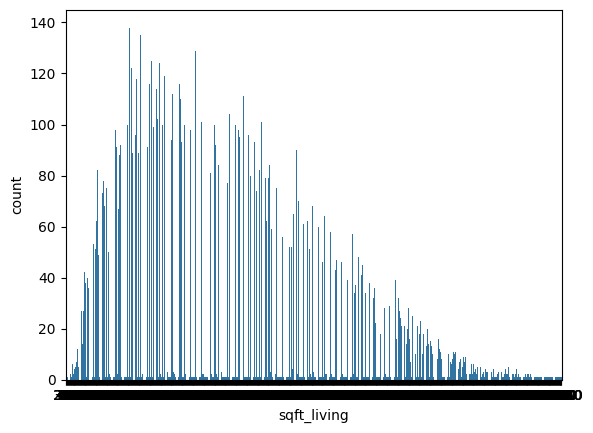

In [11]:
sqft_living_count = X['sqft_living'].value_counts()
sqft_living_count
sns.barplot(sqft_living_count)
#conclusion this feature is heavily right tailed and has outliers.

In [12]:
sqft_lot_count = X['sqft_lot'].value_counts()
sqft_lot_count
#sns.violinplot(sqft_lot_count)
# we see this also has lot of value distributions but most of the values are contained in a small region.

sqft_lot
5000    358
6000    290
4000    251
7200    220
4800    120
       ... 
5536      1
1126      1
5813      1
2388      1
1076      1
Name: count, Length: 9782, dtype: int64

<Axes: xlabel='view', ylabel='count'>

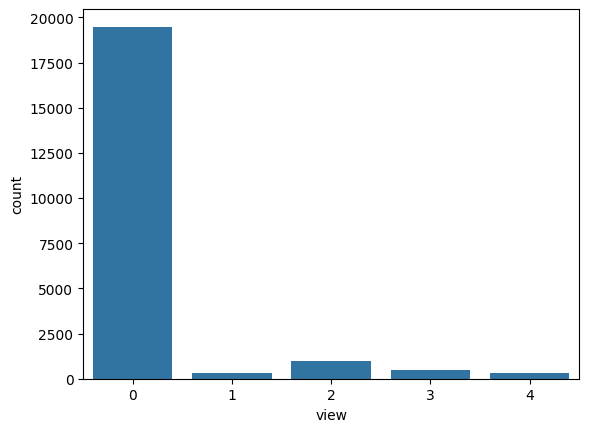

In [13]:
view_count = X['view'].value_counts()
view_count
sns.barplot(view_count)
# We observe that majority of the houses are with 0 view.

In [14]:
waterfront_count = X['waterfront'].value_counts()	
waterfront_count
# we observe that majority of the houses are without waterfront.

waterfront
0    21445
1      163
Name: count, dtype: int64

In [15]:
floors_count = X['floors'].value_counts()
floors_count
sqft_above_count,sqft_basement_count = (X['sqft_above'].value_counts(), X['sqft_basement'].value_counts())
sqft_basement_count, sqft_basement_count
# We observe that most of the houses are either 1, 2 or 1..5 floors.
# We observe that most of the houses are without sqft_above
# We observe that most of the houses are without basement
#sns.boxplot(sqft_basement_count)

(sqft_basement
 0       13123
 600       221
 700       218
 500       214
 800       206
         ...  
 508         1
 2810        1
 20          1
 274         1
 248         1
 Name: count, Length: 306, dtype: int64,
 sqft_basement
 0       13123
 600       221
 700       218
 500       214
 800       206
         ...  
 508         1
 2810        1
 20          1
 274         1
 248         1
 Name: count, Length: 306, dtype: int64)

In [16]:
condition_count,grade_count = (X['condition'].value_counts(), X['grade'].value_counts())
condition_count,grade_count
#sns.barplot(grade_count)
#most houses are graded as 7, 8, 6, 9 and the distribution is almost normal around 7.5
#sns.barplot(condition_count)
condition_count
# most houses are conditioned as 3, 4, 5 with few exceptions of 2 and 1.

condition
3    14027
4     5678
5     1701
2      172
1       30
Name: count, dtype: int64

In [17]:
yr_built_count, yr_renovated_count = X['yr_built'].value_counts(), X['yr_renovated'].value_counts()
yr_built_count, yr_renovated_count
#sns.histplot(X['yr_built'])
#sns.histplot(X['yr_renovated'])
# We have an increasing trend in the built year and number of houses so we can say most of the houses are comparetively new
yr_renovated_count
# We see that most of the houses are not renovated. This agrees with our earlier observation of houses being relatively new.
yr_built_count

yr_built
2014    558
2006    454
2005    450
2004    433
2003    422
       ... 
1933     30
1901     29
1902     27
1935     24
1934     21
Name: count, Length: 116, dtype: int64

<Axes: xlabel='sqft_living15', ylabel='Count'>

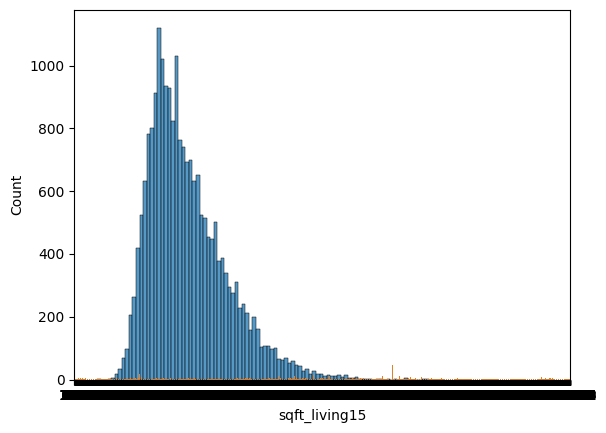

In [18]:
sqft_living15_count, sqft_lot15_count = X['sqft_living15'].value_counts(), X['sqft_lot15'].value_counts()
sns.histplot(X['sqft_living15'])
# we see that sqft_living15 is normally distributed with slight right skewness
sns.barplot(sqft_lot15_count)

In [19]:
zipcode_count = X['zipcode'].value_counts()
len(zipcode_count)
lat_count= X['lat'].value_counts()
len(lat_count)
long_count = X['long'].value_counts()
len(long_count)


752

# We have total 70 different zipcodes. 5034 lat_count and 752 longitude counts. As longitude and latitude together will give the same info as the zipcode, Later we may drop long, lat features and use the categorical encoding of the zipcode.

## Base Model Linear Regression

In [20]:

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size= 0.2, random_state= 23)
model1 = LinearRegression()
model1.fit(Xtrain, ytrain)
ytrain_pred = model1.predict(Xtrain)
ytest_pred = model1.predict(Xtest)
r2score_train = r2_score(ytrain, ytrain_pred)
r2score_test = r2_score(ytest, ytest_pred)
mse_train = mean_squared_error(ytrain, ytrain_pred)
mse_test = mean_squared_error(ytest, ytest_pred)
r2score_test, r2score_train
#mse_test, mse_train


(0.7101533638890593, 0.697015186545437)

## Base Model KNN Regression

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
Xtrain, Xtest, ytrain, ytest = train_test_split(X, y, test_size= 0.2, random_state= 23)
model2 = KNeighborsRegressor()
model2.fit(Xtrain, ytrain)
ytrain_pred = model2.predict(Xtrain)
ytest_pred = model2.predict(Xtest)
r2score_train = r2_score(ytrain, ytrain_pred)
r2score_test = r2_score(ytest, ytest_pred)
mse_train = mean_squared_error(ytrain, ytrain_pred)
mse_test = mean_squared_error(ytest, ytest_pred)
r2score_test, r2score_train
#mse_test, mse_train
# The base model conclusion tell us that the Linear regression is a better choice so we will decide on the features importance mainly via the linear regression model.


(0.49794661656993067, 0.6770885083316471)

In [22]:
y.head()

0    221900.0
1    538000.0
2    180000.0
3    604000.0
4    510000.0
Name: price, dtype: float64

In [23]:
X.columns

Index(['date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='str')

# Date, Bedrooms, Bathrooms, 

In [24]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler1 = StandardScaler()
scaler2 = MinMaxScaler()
xtrain_scaled = pd.DataFrame(scaler1.fit_transform(Xtrain), columns=Xtrain.columns)
xtest_scaled = pd.DataFrame(scaler1.fit_transform(Xtest), columns = Xtrain.columns)

model1.fit(xtrain_scaled, ytrain)
ytrain_pred = model1.predict(xtrain_scaled)
ytest_pred = model1.predict(xtest_scaled)

r2score_train = r2_score(ytrain, ytrain_pred)
r2score_test = r2_score(ytest, ytest_pred)
mse_train = mean_squared_error(ytrain, ytrain_pred)
mse_test = mean_squared_error(ytest, ytest_pred)
r2score_test, r2score_train
r2score_test, r2score_train


(0.7101969866833944, 0.697015186545437)

In [25]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
scaler1 = StandardScaler()
scaler2 = MinMaxScaler()
xtrain_scaled = pd.DataFrame(scaler2.fit_transform(Xtrain), columns=Xtrain.columns)
xtest_scaled = pd.DataFrame(scaler2.fit_transform(Xtest), columns = Xtrain.columns)
ytrain_pred = model1.predict(xtrain_scaled)
ytest_pred = model1.predict(xtest_scaled)

r2score_train = r2_score(ytrain, ytrain_pred)
r2score_test = r2_score(ytest, ytest_pred)
mse_train = mean_squared_error(ytrain, ytrain_pred)
mse_test = mean_squared_error(ytest, ytest_pred)
r2score_test, r2score_train

(0.12584475952384966, 0.07217397904406597)

In [26]:
model1.coef_

array([     0.        , -31304.56585708,  29315.48514451,  80716.67230874,
         6779.25906884,   4342.43473895,  50789.13667653,  38284.74667145,
        17379.56304306, 111102.01174148,  74717.32710497,  27303.48330111,
       -75183.35493482,   8803.61829147, -31329.19648322,  83843.79892708,
       -31104.9998365 ,  19297.36157746, -10980.06819993])

In [27]:
feat_importances = pd.Series(model1.coef_.flatten(), index=X.columns)
sorted_importances = feat_importances.sort_values(ascending=False)
print(sorted_importances)


grade            111102.011741
lat               83843.798927
sqft_living       80716.672309
sqft_above        74717.327105
waterfront        50789.136677
view              38284.746671
bathrooms         29315.485145
sqft_basement     27303.483301
sqft_living15     19297.361577
condition         17379.563043
yr_renovated       8803.618291
sqft_lot           6779.259069
floors             4342.434739
date                  0.000000
sqft_lot15       -10980.068200
long             -31104.999837
bedrooms         -31304.565857
zipcode          -31329.196483
yr_built         -75183.354935
dtype: float64


# From the above dataframe we see that Waterfront, View, grade,  Bedroom, bathrooms, condition, floors, yr_built, zipcode,sqft_living, sqft_above, sqft_basement, yr_renovated, sqft_living15, sqft_lot15 is the order of the features. We see that Date is almost a negligible feature and lat, long are exceptionally relavent features but as lat,long is already included in the zipcode so it may be a better option to drop lat and long features.

In [28]:
X1 = X.drop(['lat', 'long'], axis = 1)
X1.head()

,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,sqft_living15,sqft_lot15
0,20141015,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,98178,1340,5650
1,20141015,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,98125,1690,7639
2,20141015,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,98028,2720,8062
3,20141015,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,98136,1360,5000
4,20141015,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,98074,1800,7503


In [29]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
model1x = LinearRegression()
scaler1 = StandardScaler()
scaler2 = MinMaxScaler()
X1train, X1test, ytrain, ytest = train_test_split(X1, y, test_size= 0.2, random_state= 23)
x1train_scaled = pd.DataFrame(scaler1.fit_transform(X1train), columns=X1train.columns)
x1test_scaled = pd.DataFrame(scaler1.fit_transform(X1test), columns = X1train.columns)
model1x.fit(x1train_scaled, ytrain)
ytrain_pred = model1x.predict(x1train_scaled)
ytest_pred = model1x.predict(x1test_scaled)
r2score_train = r2_score(ytrain, ytrain_pred)
r2score_test = r2_score(ytest, ytest_pred)
mse_train = mean_squared_error(ytrain, ytrain_pred)
mse_test = mean_squared_error(ytest, ytest_pred)
r2score_test, r2score_train







(0.6654880852946002, 0.6506447659339021)

In [30]:
feat_importances = pd.Series(model1x.coef_.flatten(), index=X1.columns)
sorted_importances = feat_importances.sort_values(ascending=False)
print(sorted_importances)

grade            139446.419525
sqft_living       75060.009346
sqft_above        62898.756040
waterfront        50196.055360
sqft_basement     37806.660366
bathrooms         32896.955079
view              30639.964996
sqft_living15     21018.921126
floors            15681.560913
condition         12697.478582
yr_renovated       4699.544598
sqft_lot           2163.854176
zipcode             103.616075
date                  0.000000
sqft_lot15       -16167.517630
bedrooms         -34817.137848
yr_built        -103896.181272
dtype: float64


# We see that the performance of the base model has gone down so it may be a better option to keep lat and long and drop the zipcode.

In [31]:
X2 = X.drop(['date', 'zipcode'], axis = 1)
X2.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,0,47.5112,-122.257,1340,5650
1,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,1991,47.7210,-122.319,1690,7639
2,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,0,47.7379,-122.233,2720,8062
3,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,0,47.5208,-122.393,1360,5000
4,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,0,47.6168,-122.045,1800,7503


In [32]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
model1x = LinearRegression()
scaler1 = StandardScaler()
scaler2 = MinMaxScaler()
X2train, X2test, ytrain, ytest = train_test_split(X2, y, test_size= 0.2, random_state= 23)
x2train_scaled = pd.DataFrame(scaler1.fit_transform(X2train), columns=X1train.columns)
x2test_scaled = pd.DataFrame(scaler1.fit_transform(X2test), columns = X1train.columns)
model1x.fit(x2train_scaled, ytrain)
ytrain_pred = model1x.predict(x2train_scaled)
ytest_pred = model1x.predict(x2test_scaled)
r2score_train = r2_score(ytrain, ytrain_pred)
r2score_test = r2_score(ytest, ytest_pred)
mse_train = mean_squared_error(ytrain, ytrain_pred)
mse_test = mean_squared_error(ytest, ytest_pred)
r2score_test, r2score_train


(0.7060643866877532, 0.6926271682076865)

In [33]:
feat_importances = pd.Series(model1x.coef_.flatten(), index=X2.columns)
sorted_importances = feat_importances.sort_values(ascending=False)
print(sorted_importances)

grade            112582.332455
sqft_living       79737.631943
lat               77908.636851
sqft_above        74206.718358
waterfront        51155.780010
view              35595.129308
bathrooms         30328.217382
sqft_basement     26225.949410
sqft_living15     23138.910740
condition         20366.833992
yr_renovated       9424.737543
sqft_lot           6885.450018
floors             1101.190232
sqft_lot15       -11328.351465
long             -17272.811772
bedrooms         -29874.258666
yr_built         -70446.040477
dtype: float64


In [34]:
X.columns

Index(['date', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15'],
      dtype='str')

In [35]:
X3 = X.drop(['date', 'zipcode', 'sqft_lot'], axis = 1)
X3.head()

,bedrooms,bathrooms,sqft_living,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,lat,long,sqft_living15,sqft_lot15
0,3,1.00,1180,1.0,0,0,3,7,1180,0,1955,0,47.5112,-122.257,1340,5650
1,3,2.25,2570,2.0,0,0,3,7,2170,400,1951,1991,47.7210,-122.319,1690,7639
2,2,1.00,770,1.0,0,0,3,6,770,0,1933,0,47.7379,-122.233,2720,8062
3,4,3.00,1960,1.0,0,0,5,7,1050,910,1965,0,47.5208,-122.393,1360,5000
4,3,2.00,1680,1.0,0,0,3,8,1680,0,1987,0,47.6168,-122.045,1800,7503


In [36]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
model1x3 = LinearRegression()
scaler1 = StandardScaler()
scaler2 = MinMaxScaler()
X3train, X3test, ytrain, ytest = train_test_split(X3, y, test_size= 0.2, random_state= 23)
x3train_scaled = pd.DataFrame(scaler1.fit_transform(X3train), columns=X3train.columns)
x3test_scaled = pd.DataFrame(scaler1.fit_transform(X3test), columns = X3train.columns)
model1x3.fit(x3train_scaled, ytrain)
ytrain_pred = model1x3.predict(x3train_scaled)
ytest_pred = model1x3.predict(x3test_scaled)
r2score_train = r2_score(ytrain, ytrain_pred)
r2score_test = r2_score(ytest, ytest_pred)
mse_train = mean_squared_error(ytrain, ytrain_pred)
mse_test = mean_squared_error(ytest, ytest_pred)

r2score_test, r2score_train



(0.7062102191409597, 0.692468439423477)

In [37]:
feat_importances = pd.Series(model1x3.coef_.flatten(), index=X3.columns)
sorted_importances = feat_importances.sort_values(ascending=False)
print(sorted_importances)

grade            112669.157553
sqft_living       80057.485661
lat               77768.591023
sqft_above        74578.377125
waterfront        51060.155667
view              35821.969582
bathrooms         30403.207258
sqft_basement     26191.576553
sqft_living15     22655.191745
condition         20247.955172
yr_renovated       9349.244143
floors              939.756924
sqft_lot15        -6411.843898
long             -16894.798977
bedrooms         -30045.243703
yr_built         -70725.845073
dtype: float64


# As we see that we do not have much of the changes in the performance of the model we can say that such features are keeping the model stable or to say that they are relevant for the model. So Now we move to a change of the model and try to look at the performance of other model on the same features.

In [38]:
Xgdata = X3
model2 = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=10)
xgdatatrain, xgdatatest, ygdatatrain,ygdatatest = train_test_split(Xgdata, y, test_size=0.2, random_state=32)
scaled_xtrain= scaler2.fit_transform(xgdatatrain)
scaled_xtest = scaler2.transform(xgdatatest)
model2.fit(scaled_xtrain, ygdatatrain)
scaled_ytrain_pred = model2.predict(scaled_xtrain)
scaled_ytest_pred = model2.predict(scaled_xtest)
r2scorexgb_train = r2_score(ygdatatrain, scaled_ytrain_pred)
r2scorexgb_test = r2_score(ygdatatest, scaled_ytest_pred)
msexgb_train = mean_squared_error(ygdatatrain, scaled_ytrain_pred)
msexgb_test = mean_squared_error(ygdatatest, scaled_ytest_pred)
r2scorexgb_train, r2scorexgb_test


(0.994207915556834, 0.8625727300580385)

# Now we see that whether the linear regression or the XGBoost model there is a case of overfitting. We also observe that R2score on test for the linear regression was positive but it is negative for the XGboost. This may suggest that either the training and test set are in the opposite direction and a serious need of feature analysis is needed.

Data side: handle outliers, multicollinearity, feature selection, normalization/standardization, feature engineering, etc. We do teh bivariate analysis and few other operations on the individual features now to improv e the performance of the model.

In [39]:
Xgdata.columns
X5 = X.drop(['date', 'lat', 'long', 'sqft_lot'], axis = 1)
df1 = X5.join(y, how = 'right')
df1

,bedrooms,bathrooms,sqft_living,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,sqft_living15,sqft_lot15,price
0,3,1.00,1180,1.0,0,0,3,7,1180,0,1955,0,98178,1340,5650,221900.0
1,3,2.25,2570,2.0,0,0,3,7,2170,400,1951,1991,98125,1690,7639,538000.0
2,2,1.00,770,1.0,0,0,3,6,770,0,1933,0,98028,2720,8062,180000.0
3,4,3.00,1960,1.0,0,0,5,7,1050,910,1965,0,98136,1360,5000,604000.0
4,3,2.00,1680,1.0,0,0,3,8,1680,0,1987,0,98074,1800,7503,510000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21608,3,2.50,1530,3.0,0,0,3,8,1530,0,2009,0,98103,1530,1509,360000.0
21609,4,2.50,2310,2.0,0,0,3,8,2310,0,2014,0,98146,1830,7200,400000.0
21610,2,0.75,1020,2.0,0,0,3,7,1020,0,2009,0,98144,1020,2007,402101.0
21611,3,2.50,1600,2.0,0,0,3,8,1600,0,2004,0,98027,1410,1287,400000.0


<Axes: >

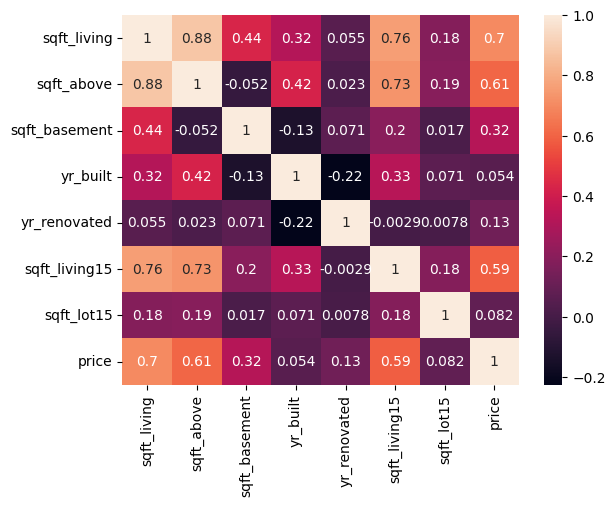

In [40]:
# Bivariate analysis of price with other features.
# As bedrooms, bathrooms, floors, waterfront, view, condition, grade, zipcode are categorical in nature we do not look at its correlation with price.
x5 = df1.drop(['bedrooms', 'bathrooms', 'floors', 'waterfront', 'view', 'condition', 'grade', 'zipcode'], axis = 1)
x5
corelations = x5.corr()
sns.heatmap(corelations, annot=True)

<Axes: xlabel='sqft_living15', ylabel='Count'>

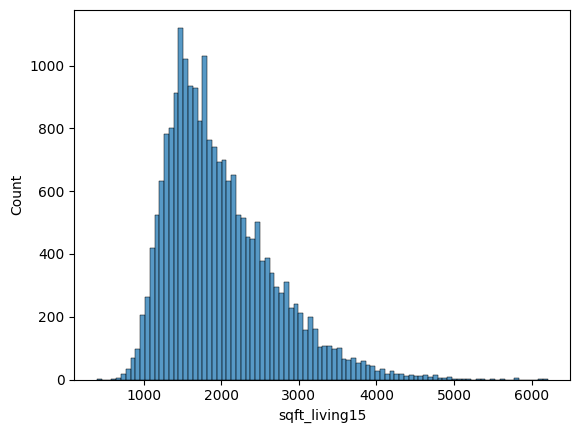

In [41]:
sns.histplot(data['sqft_living15'])

<Axes: ylabel='Count'>

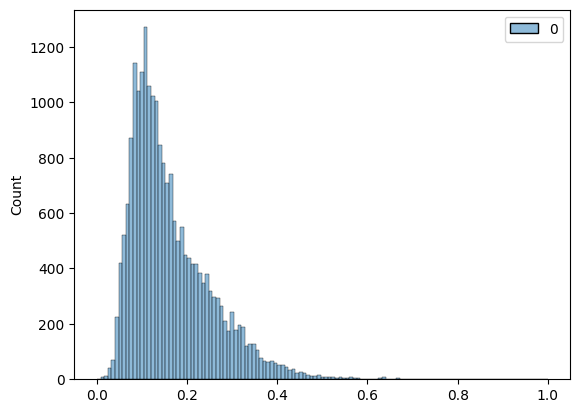

In [42]:
#sns.histplot(data['sqft_above'])
scaler3 = MinMaxScaler()
scaled_sqft_above = scaler3.fit_transform(X5['sqft_above'].values.reshape(-1,1))
sns.histplot(scaled_sqft_above)

<Axes: xlabel='sqft_living', ylabel='Count'>

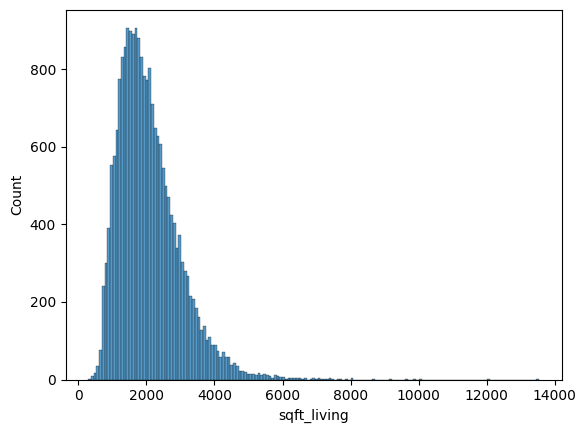

In [43]:
sns.histplot(data['sqft_living'])

From above heatmap we can see that price is strongly correlated with the features like sqft_living, sqft_above, sqft_living15 and sqft_basement. Mildly correlated with yr_renovated, sqft_lot15 and yr_built. Which kind of agrees with our hopes. We also see that sqft_living, sqft_above, sqft_living15 are almost normally distributed with right skewness so we plaot them all together to pick a range we will work with.

<Axes: xlabel='sqft_living', ylabel='Count'>

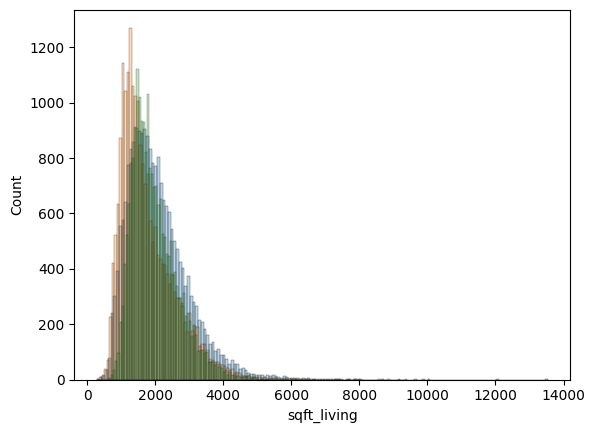

In [44]:
sns.histplot(data['sqft_living'], alpha= 0.3)
sns.histplot(data['sqft_above'], alpha = 0.3)
sns.histplot(data['sqft_living15'], alpha = 0.3)

In [45]:
a1 = X5[(X5['sqft_above'] > 5000)] #& (X5['sqft_living']> 5000) &(X5['sqft_living15']> 5000)]
X6= X5.join(df1['price'], how = 'right')
X6 = X6.drop(a1.index)
X6.isna().sum()
X6.shape



(21522, 16)

In [46]:
Xgdata = X6
y = X6['price']
model2 = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=10)
xgdatatrain, xgdatatest, ygdatatrain,ygdatatest = train_test_split(Xgdata, y, test_size=0.2, random_state=32)
scaled_xtrain= scaler2.fit_transform(xgdatatrain)
scaled_xtest = scaler2.transform(xgdatatest)
model2.fit(scaled_xtrain, ygdatatrain)
scaled_ytrain_pred = model2.predict(scaled_xtrain)
scaled_ytest_pred = model2.predict(scaled_xtest)
r2scorexgb_train = r2_score(ygdatatrain, scaled_ytrain_pred)
r2scorexgb_test = r2_score(ygdatatest, scaled_ytest_pred)
msexgb_train = mean_squared_error(ygdatatrain, scaled_ytrain_pred)
msexgb_test = mean_squared_error(ygdatatest, scaled_ytest_pred)
r2scorexgb_train, r2scorexgb_test

(0.9999941799576615, 0.9721375882337457)

Since I have got a real good train and test R2_score and both in the same range. It may be a case of overfitting, so Now I do the cross validation by running the same model with different test size and train size.

In [47]:
Xgdata = X6
model2 = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=10)
xgdatatrain, xgdatatest, ygdatatrain,ygdatatest = train_test_split(Xgdata, y, test_size=0.2, random_state=32)
scaled_xtrain= scaler2.fit_transform(xgdatatrain)
scaled_xtest = scaler2.transform(xgdatatest)
model2.fit(scaled_xtrain, ygdatatrain)
scaled_ytrain_pred = model2.predict(scaled_xtrain)
scaled_ytest_pred = model2.predict(scaled_xtest)
r2scorexgb_train = r2_score(ygdatatrain, scaled_ytrain_pred)
r2scorexgb_test = r2_score(ygdatatest, scaled_ytest_pred)
msexgb_train = mean_squared_error(ygdatatrain, scaled_ytrain_pred)
msexgb_test = mean_squared_error(ygdatatest, scaled_ytest_pred)
r2scorexgb_train, r2scorexgb_test

(0.9999941799576615, 0.9721375882337457)

In [48]:

dummies = pd.get_dummies(X6['zipcode'], prefix='encoded_zipcode', drop_first=True)
X6 = pd.concat([X6, dummies], axis=1)
X6.drop('zipcode', axis=1, inplace=True)
X6

,bedrooms,bathrooms,sqft_living,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15,price,encoded_zipcode_98002,encoded_zipcode_98003,encoded_zipcode_98004,encoded_zipcode_98005,encoded_zipcode_98006,encoded_zipcode_98007,encoded_zipcode_98008,encoded_zipcode_98010,encoded_zipcode_98011,encoded_zipcode_98014,encoded_zipcode_98019,encoded_zipcode_98022,encoded_zipcode_98023,encoded_zipcode_98024,encoded_zipcode_98027,encoded_zipcode_98028,encoded_zipcode_98029,encoded_zipcode_98030,encoded_zipcode_98031,encoded_zipcode_98032,encoded_zipcode_98033,encoded_zipcode_98034,encoded_zipcode_98038,encoded_zipcode_98039,encoded_zipcode_98040,encoded_zipcode_98042,encoded_zipcode_98045,encoded_zipcode_98052,encoded_zipcode_98053,encoded_zipcode_98055,encoded_zipcode_98056,encoded_zipcode_98058,encoded_zipcode_98059,encoded_zipcode_98065,encoded_zipcode_98070,encoded_zipcode_98072,encoded_zipcode_98074,encoded_zipcode_98075,encoded_zipcode_98077,encoded_zipcode_98092,encoded_zipcode_98102,encoded_zipcode_98103,encoded_zipcode_98105,encoded_zipcode_98106,encoded_zipcode_98107,encoded_zipcode_98108,encoded_zipcode_98109,encoded_zipcode_98112,encoded_zipcode_98115,encoded_zipcode_98116,encoded_zipcode_98117,encoded_zipcode_98118,encoded_zipcode_98119,encoded_zipcode_98122,encoded_zipcode_98125,encoded_zipcode_98126,encoded_zipcode_98133,encoded_zipcode_98136,encoded_zipcode_98144,encoded_zipcode_98146,encoded_zipcode_98148,encoded_zipcode_98155,encoded_zipcode_98166,encoded_zipcode_98168,encoded_zipcode_98177,encoded_zipcode_98178,encoded_zipcode_98188,encoded_zipcode_98198,encoded_zipcode_98199
0,3,1.00,1180,1.0,0,0,3,7,1180,0,1955,0,1340,5650,221900.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,3,2.25,2570,2.0,0,0,3,7,2170,400,1951,1991,1690,7639,538000.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,2,1.00,770,1.0,0,0,3,6,770,0,1933,0,2720,8062,180000.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,4,3.00,1960,1.0,0,0,5,7,1050,910,1965,0,1360,5000,604000.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
4,3,2.00,1680,1.0,0,0,3,8,1680,0,1987,0,1800,7503,510000.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,Fals

In [49]:
#from sklearn.preprocessing import OneHotEncoder

#data = X6['zipcode']
#data = data.values.reshape(-1,1)
#encoder = OneHotEncoder(sparse_output=False)
#encoded_zipcode = encoder.fit_transform(data)

#print(encoded_zipcode)
#print("Categories found:", encoder.categories_)

In [50]:
#encoded_df = pd.DataFrame(
#    encoded_zipcode, 
#    columns=encoder.get_feature_names_out(['encoded_zipcode']),
#    index=X6.index  
#)
#X6 = pd.concat([X6, encoded_df], axis = 1)
#X6

In [51]:
Xgdata = X6.drop('price', axis = 1)
y = X6['price']
model2 = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=10)
xgdatatrain, xgdatatest, ygdatatrain,ygdatatest = train_test_split(Xgdata, y, test_size=0.3, random_state=32)
scaled_xtrain= scaler2.fit_transform(xgdatatrain)
scaled_xtest = scaler2.transform(xgdatatest)
model2.fit(scaled_xtrain, ygdatatrain)
scaled_ytrain_pred = model2.predict(scaled_xtrain)
scaled_ytest_pred = model2.predict(scaled_xtest)
r2scorexgb_train = r2_score(ygdatatrain, scaled_ytrain_pred)
r2scorexgb_test = r2_score(ygdatatest, scaled_ytest_pred)
msexgb_train = mean_squared_error(ygdatatrain, scaled_ytrain_pred)
msexgb_test = mean_squared_error(ygdatatest, scaled_ytest_pred)
r2scorexgb_train, r2scorexgb_test

(0.980719894359327, 0.8640573126710351)

In [52]:

a2 = X6[X6['sqft_above'] + X6['sqft_basement'] != X6['sqft_living']]
len(a2)

    

# so we can drop sqft_above and sqft_basement

0

In [53]:
Xgdata = X6.drop(['price', 'sqft_above', 'sqft_basement'], axis = 1)
y = X6['price']
model2 = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=10)
xgdatatrain, xgdatatest, ygdatatrain,ygdatatest = train_test_split(Xgdata, y, test_size=0.3, random_state=32)
scaled_xtrain= scaler2.fit_transform(xgdatatrain)
scaled_xtest = scaler2.transform(xgdatatest)
model2.fit(scaled_xtrain, ygdatatrain)
scaled_ytrain_pred = model2.predict(scaled_xtrain)
scaled_ytest_pred = model2.predict(scaled_xtest)
r2scorexgb_train = r2_score(ygdatatrain, scaled_ytrain_pred)
r2scorexgb_test = r2_score(ygdatatest, scaled_ytest_pred)
msexgb_train = mean_squared_error(ygdatatrain, scaled_ytrain_pred)
msexgb_test = mean_squared_error(ygdatatest, scaled_ytest_pred)
r2scorexgb_train, r2scorexgb_test

(0.9793730727307091, 0.8605094252554665)

In [54]:
X6['yr_built'] = X6['yr_built'] - 1900
X6['yr_renovated'] = X6['yr_renovated'].apply(lambda x: 1 if x != 0 else 0)     
X6

,bedrooms,bathrooms,sqft_living,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15,price,encoded_zipcode_98002,encoded_zipcode_98003,encoded_zipcode_98004,encoded_zipcode_98005,encoded_zipcode_98006,encoded_zipcode_98007,encoded_zipcode_98008,encoded_zipcode_98010,encoded_zipcode_98011,encoded_zipcode_98014,encoded_zipcode_98019,encoded_zipcode_98022,encoded_zipcode_98023,encoded_zipcode_98024,encoded_zipcode_98027,encoded_zipcode_98028,encoded_zipcode_98029,encoded_zipcode_98030,encoded_zipcode_98031,encoded_zipcode_98032,encoded_zipcode_98033,encoded_zipcode_98034,encoded_zipcode_98038,encoded_zipcode_98039,encoded_zipcode_98040,encoded_zipcode_98042,encoded_zipcode_98045,encoded_zipcode_98052,encoded_zipcode_98053,encoded_zipcode_98055,encoded_zipcode_98056,encoded_zipcode_98058,encoded_zipcode_98059,encoded_zipcode_98065,encoded_zipcode_98070,encoded_zipcode_98072,encoded_zipcode_98074,encoded_zipcode_98075,encoded_zipcode_98077,encoded_zipcode_98092,encoded_zipcode_98102,encoded_zipcode_98103,encoded_zipcode_98105,encoded_zipcode_98106,encoded_zipcode_98107,encoded_zipcode_98108,encoded_zipcode_98109,encoded_zipcode_98112,encoded_zipcode_98115,encoded_zipcode_98116,encoded_zipcode_98117,encoded_zipcode_98118,encoded_zipcode_98119,encoded_zipcode_98122,encoded_zipcode_98125,encoded_zipcode_98126,encoded_zipcode_98133,encoded_zipcode_98136,encoded_zipcode_98144,encoded_zipcode_98146,encoded_zipcode_98148,encoded_zipcode_98155,encoded_zipcode_98166,encoded_zipcode_98168,encoded_zipcode_98177,encoded_zipcode_98178,encoded_zipcode_98188,encoded_zipcode_98198,encoded_zipcode_98199
0,3,1.00,1180,1.0,0,0,3,7,1180,0,55,0,1340,5650,221900.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,3,2.25,2570,2.0,0,0,3,7,2170,400,51,1,1690,7639,538000.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,2,1.00,770,1.0,0,0,3,6,770,0,33,0,2720,8062,180000.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,4,3.00,1960,1.0,0,0,5,7,1050,910,65,0,1360,5000,604000.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
4,3,2.00,1680,1.0,0,0,3,8,1680,0,87,0,1800,7503,510000.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False

In [55]:
Xgdata = X6.drop(['price', 'sqft_above', 'sqft_basement'], axis = 1)
y = X6['price']
model2 = xgb.XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=10)
xgdatatrain, xgdatatest, ygdatatrain,ygdatatest = train_test_split(Xgdata, y, test_size=0.3, random_state=32)
scaled_xtrain= scaler2.fit_transform(xgdatatrain)
scaled_xtest = scaler2.transform(xgdatatest)
model2.fit(scaled_xtrain, ygdatatrain)
scaled_ytrain_pred = model2.predict(scaled_xtrain)
scaled_ytest_pred = model2.predict(scaled_xtest)
r2scorexgb_train = r2_score(ygdatatrain, scaled_ytrain_pred)
r2scorexgb_test = r2_score(ygdatatest, scaled_ytest_pred)
msexgb_train = mean_squared_error(ygdatatrain, scaled_ytrain_pred)
msexgb_test = mean_squared_error(ygdatatest, scaled_ytest_pred)
r2scorexgb_train, r2scorexgb_test

(0.9797659030199752, 0.8613869990039761)

,bedrooms,bathrooms,sqft_living,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,yr_renovated,sqft_living15,sqft_lot15,price,encoded_zipcode_98002,encoded_zipcode_98003,encoded_zipcode_98004,encoded_zipcode_98005,encoded_zipcode_98006,encoded_zipcode_98007,encoded_zipcode_98008,encoded_zipcode_98010,encoded_zipcode_98011,encoded_zipcode_98014,encoded_zipcode_98019,encoded_zipcode_98022,encoded_zipcode_98023,encoded_zipcode_98024,encoded_zipcode_98027,encoded_zipcode_98028,encoded_zipcode_98029,encoded_zipcode_98030,encoded_zipcode_98031,encoded_zipcode_98032,encoded_zipcode_98033,encoded_zipcode_98034,encoded_zipcode_98038,encoded_zipcode_98039,encoded_zipcode_98040,encoded_zipcode_98042,encoded_zipcode_98045,encoded_zipcode_98052,encoded_zipcode_98053,encoded_zipcode_98055,encoded_zipcode_98056,encoded_zipcode_98058,encoded_zipcode_98059,encoded_zipcode_98065,encoded_zipcode_98070,encoded_zipcode_98072,encoded_zipcode_98074,encoded_zipcode_98075,encoded_zipcode_98077,encoded_zipcode_98092,encoded_zipcode_98102,encoded_zipcode_98103,encoded_zipcode_98105,encoded_zipcode_98106,encoded_zipcode_98107,encoded_zipcode_98108,encoded_zipcode_98109,encoded_zipcode_98112,encoded_zipcode_98115,encoded_zipcode_98116,encoded_zipcode_98117,encoded_zipcode_98118,encoded_zipcode_98119,encoded_zipcode_98122,encoded_zipcode_98125,encoded_zipcode_98126,encoded_zipcode_98133,encoded_zipcode_98136,encoded_zipcode_98144,encoded_zipcode_98146,encoded_zipcode_98148,encoded_zipcode_98155,encoded_zipcode_98166,encoded_zipcode_98168,encoded_zipcode_98177,encoded_zipcode_98178,encoded_zipcode_98188,encoded_zipcode_98198,encoded_zipcode_98199
0,3,1.00,1180,1.0,0,0,3,7,1180,0,55,0,1340,5650,221900.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,3,2.25,2570,2.0,0,0,3,7,2170,400,51,1,1690,7639,538000.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,2,1.00,770,1.0,0,0,3,6,770,0,33,0,2720,8062,180000.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,4,3.00,1960,1.0,0,0,5,7,1050,910,65,0,1360,5000,604000.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
4,3,2.00,1680,1.0,0,0,3,8,1680,0,87,0,1800,7503,510000.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False

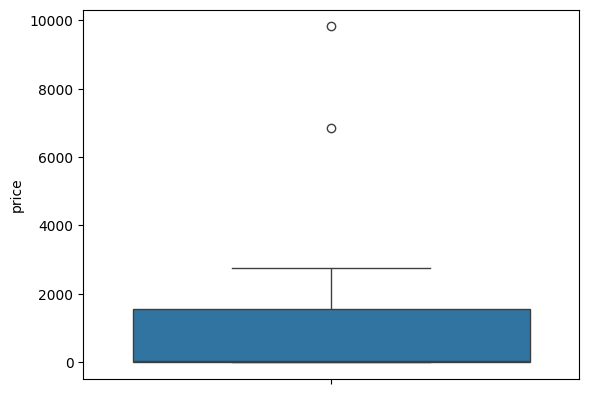

In [56]:
# Relation between price and rooms 
a1= X6.groupby('bedrooms')['price'].count()
sns.boxplot(a1)
a1
X6 = X6[~X6['bedrooms'].isin([11, 33])]
X6

In [57]:
a2 = X6.groupby('floors')['price'].count()
a2

floors
1.0    10678
1.5     1907
2.0     8166
2.5      154
3.0      608
3.5        7
Name: price, dtype: int64

In [58]:
a3 = X6.groupby('grade')['price'].count()
a3

grade
1        1
3        3
4       29
5      242
6     2038
7     8979
8     6065
9     2611
10    1124
11     360
12      63
13       5
Name: price, dtype: int64

In [59]:
aa= X6.groupby('sqft_basement')['price'].count()
aa

sqft_basement
0       13067
10          2
20          1
40          4
50         11
        ...  
2810        1
2850        1
3260        1
3500        1
4820        1
Name: price, Length: 301, dtype: int64

In [60]:
a4 = X6.groupby('yr_built')['price'].count()
a4


yr_built
0       87
1       29
2       27
3       46
4       44
      ... 
111    130
112    170
113    200
114    557
115     38
Name: price, Length: 116, dtype: int64

Now we put the final nail to the coffin by removing the columns we think are not affecting the performance.

In [61]:
X6 = X6.drop(['yr_built','view', 'sqft_lot15'], axis = 1)
X6

,bedrooms,bathrooms,sqft_living,floors,waterfront,condition,grade,sqft_above,sqft_basement,yr_renovated,sqft_living15,price,encoded_zipcode_98002,encoded_zipcode_98003,encoded_zipcode_98004,encoded_zipcode_98005,encoded_zipcode_98006,encoded_zipcode_98007,encoded_zipcode_98008,encoded_zipcode_98010,encoded_zipcode_98011,encoded_zipcode_98014,encoded_zipcode_98019,encoded_zipcode_98022,encoded_zipcode_98023,encoded_zipcode_98024,encoded_zipcode_98027,encoded_zipcode_98028,encoded_zipcode_98029,encoded_zipcode_98030,encoded_zipcode_98031,encoded_zipcode_98032,encoded_zipcode_98033,encoded_zipcode_98034,encoded_zipcode_98038,encoded_zipcode_98039,encoded_zipcode_98040,encoded_zipcode_98042,encoded_zipcode_98045,encoded_zipcode_98052,encoded_zipcode_98053,encoded_zipcode_98055,encoded_zipcode_98056,encoded_zipcode_98058,encoded_zipcode_98059,encoded_zipcode_98065,encoded_zipcode_98070,encoded_zipcode_98072,encoded_zipcode_98074,encoded_zipcode_98075,encoded_zipcode_98077,encoded_zipcode_98092,encoded_zipcode_98102,encoded_zipcode_98103,encoded_zipcode_98105,encoded_zipcode_98106,encoded_zipcode_98107,encoded_zipcode_98108,encoded_zipcode_98109,encoded_zipcode_98112,encoded_zipcode_98115,encoded_zipcode_98116,encoded_zipcode_98117,encoded_zipcode_98118,encoded_zipcode_98119,encoded_zipcode_98122,encoded_zipcode_98125,encoded_zipcode_98126,encoded_zipcode_98133,encoded_zipcode_98136,encoded_zipcode_98144,encoded_zipcode_98146,encoded_zipcode_98148,encoded_zipcode_98155,encoded_zipcode_98166,encoded_zipcode_98168,encoded_zipcode_98177,encoded_zipcode_98178,encoded_zipcode_98188,encoded_zipcode_98198,encoded_zipcode_98199
0,3,1.00,1180,1.0,0,3,7,1180,0,0,1340,221900.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,3,2.25,2570,2.0,0,3,7,2170,400,1,1690,538000.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,2,1.00,770,1.0,0,3,6,770,0,0,2720,180000.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,4,3.00,1960,1.0,0,5,7,1050,910,0,1360,604000.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
4,3,2.00,1680,1.0,0,3,8,1680,0,0,1800,510000.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,

In [62]:
X6 = X6.drop(['sqft_above', 'sqft_basement', 'yr_renovated', 'floors', 'bathrooms', 'bedrooms'], axis= 1)
#, 'bathrooms', 'floors', 'yr_renovated'

We have done all the necessary changes except maybe few other possible outliers removal. But as we have very high train set performance and low test set performance and this seems a case of overfitting we move to the Hyperparameter tuning to tackle the issue of overfitting.

In [63]:
from sklearn.model_selection import GridSearchCV
Xgdata=X6.drop('price', axis = 1)
y = X6['price']
xgdatatrain, xgdatatest, ygdatatrain,ygdatatest = train_test_split(Xgdata, y, test_size=0.2, random_state=32)
estimato = xgb.XGBRegressor()
param_grids = {'n_estimators':[100, 150, 200, 250, 300, 350, 400], 'learning_rate': [0.01, 0.1, 0.001, 0.4, 0.9], 'max_depth': [3, 5, 7, 10, 12]}
clf = GridSearchCV(estimator= estimato, param_grid=param_grids, cv = 5, verbose = 2, scoring= 'r2', n_jobs=-1)
#sorted(clf.cv_results_.keys())
clf.fit(xgdatatrain, ygdatatrain)
#GridSearchCV(estimator= estimato,
#             param_grid={'C': [1, 10], 'kernel': ('linear', 'rbf')})
#sorted(clf.cv_results_.keys())

# 5. Results of the search
print("Best Parameters:", clf.best_params_)
print("Best CV Score (Validation):", clf.best_score_)

# 6. THE FINAL EXAM (Evaluation)
# Use the best model found to predict the hidden test set
best_model = clf.best_estimator_
test_score = best_model.score(xgdatatest, ygdatatest)

print("Final R2 Score on Test Set:", test_score)

#print("Best Parameters:", clf.best_params_)
#print("Best R2 Score:", clf.best_score_)

# 6. See all technical metadata keys
#print(sorted(clf.cv_results_.keys()))



Fitting 5 folds for each of 175 candidates, totalling 875 fits
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=100; total time=   0.2s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=150; total time=   0.3s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=150; total time=   0.3s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=150; total time=   0.3s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=150; total time=   0.3s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=150; total time=   0.3s
[CV] END ..learning_rate=0.01, max_depth=3, n_estimators=200; total time=   0.3s
[CV] END ..learning_rate=0.01, max_depth=3, n_

In [64]:
X6.columns

Index(['sqft_living', 'waterfront', 'condition', 'grade', 'sqft_living15',
       'price', 'encoded_zipcode_98002', 'encoded_zipcode_98003',
       'encoded_zipcode_98004', 'encoded_zipcode_98005',
       'encoded_zipcode_98006', 'encoded_zipcode_98007',
       'encoded_zipcode_98008', 'encoded_zipcode_98010',
       'encoded_zipcode_98011', 'encoded_zipcode_98014',
       'encoded_zipcode_98019', 'encoded_zipcode_98022',
       'encoded_zipcode_98023', 'encoded_zipcode_98024',
       'encoded_zipcode_98027', 'encoded_zipcode_98028',
       'encoded_zipcode_98029', 'encoded_zipcode_98030',
       'encoded_zipcode_98031', 'encoded_zipcode_98032',
       'encoded_zipcode_98033', 'encoded_zipcode_98034',
       'encoded_zipcode_98038', 'encoded_zipcode_98039',
       'encoded_zipcode_98040', 'encoded_zipcode_98042',
       'encoded_zipcode_98045', 'encoded_zipcode_98052',
       'encoded_zipcode_98053', 'encoded_zipcode_98055',
       'encoded_zipcode_98056', 'encoded_zipcode_98058',
    

In [65]:
"""def evaluate_regression_model(model, X_train, X_test, y_train, y_test, verbose=True):
    # Predictions
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Metrics
    results = {
        “train_r2”: r2_score(y_train, y_train_pred),
        “test_r2": r2_score(y_test, y_test_pred),
        “train_mse”: mean_squared_error(y_train, y_train_pred),
        “test_mse”: mean_squared_error(y_test, y_test_pred),
        “train_rmse”: np.sqrt(mean_squared_error(y_train, y_train_pred)),
        “test_rmse”: np.sqrt(mean_squared_error(y_test, y_test_pred)),
        “train_mae”: mean_absolute_error(y_train, y_train_pred),
        “test_mae”: mean_absolute_error(y_test, y_test_pred),
    }

#    if verbose:
#        print(“=== Model Evaluation ===“)
#        for k, v in results.items():
#            print(f”{k}: {v:.4f}“)"""

'def evaluate_regression_model(model, X_train, X_test, y_train, y_test, verbose=True):\n\xa0\xa0\xa0\xa0# Predictions\n\xa0\xa0\xa0\xa0y_train_pred = model.predict(X_train)\n\xa0\xa0\xa0\xa0y_test_pred = model.predict(X_test)\n\n\xa0\xa0\xa0\xa0# Metrics\n\xa0\xa0\xa0\xa0results = {\n\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0“train_r2”: r2_score(y_train, y_train_pred),\n\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0“test_r2": r2_score(y_test, y_test_pred),\n\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0“train_mse”: mean_squared_error(y_train, y_train_pred),\n\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0“test_mse”: mean_squared_error(y_test, y_test_pred),\n\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0“train_rmse”: np.sqrt(mean_squared_error(y_train, y_train_pred)),\n\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0“test_rmse”: np.sqrt(mean_squared_error(y_test, y_test_pred)),\n\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0“train_mae”: mean_absolute_error(y_train, y_train_pred),\n\xa0\xa0\xa0\xa0\xa0\xa0\xa0\xa0“test_mae”: mean_absolute_error(y_test, y_test_pred),\n\xa0\xa0\xa0\xa

## Fine Tuning
Now we do the final tuning of our model with the final set of features
We will start with our hyperparameters {'learning_rate': 0.4, 'max_depth': 3, 'n_estimators': 300}
Our final set of features are 'sqft_living', 'waterfront', 'condition', 'grade', 'sqft_living15' and 'zipcode'.
Among these zipcode, condition, grade,  waterfront are the categorical variables and sqft_living, sqft_


In [66]:
Xgdata = X6
y = X6['price']
model2 = xgb.XGBRegressor(n_estimators=300, learning_rate=0.4, max_depth=3)
xgdatatrain, xgdatatest, ygdatatrain,ygdatatest = train_test_split(Xgdata, y, test_size=0.2, random_state=32)
scaled_xtrain= scaler2.fit_transform(xgdatatrain)
scaled_xtest = scaler2.transform(xgdatatest)
model2.fit(scaled_xtrain, ygdatatrain)
scaled_ytrain_pred = model2.predict(scaled_xtrain)
scaled_ytest_pred = model2.predict(scaled_xtest)
r2scorexgb_train = r2_score(ygdatatrain, scaled_ytrain_pred)
r2scorexgb_test = r2_score(ygdatatest, scaled_ytest_pred)
msexgb_train = mean_squared_error(ygdatatrain, scaled_ytrain_pred)
msexgb_test = mean_squared_error(ygdatatest, scaled_ytest_pred)
r2scorexgb_train, r2scorexgb_test

(0.9995755523884462, 0.9883270301168032)

In [67]:
Xgdata = X6.drop(['condition', 'sqft_living15'], axis = 1)
y = X6['price']
model2 = xgb.XGBRegressor(n_estimators=300, learning_rate=0.4, max_depth=3)
xgdatatrain, xgdatatest, ygdatatrain,ygdatatest = train_test_split(Xgdata, y, test_size=0.2, random_state=32)
scaled_xtrain= scaler2.fit_transform(xgdatatrain)
scaled_xtest = scaler2.transform(xgdatatest)
model2.fit(scaled_xtrain, ygdatatrain)
scaled_ytrain_pred = model2.predict(scaled_xtrain)
scaled_ytest_pred = model2.predict(scaled_xtest)
r2scorexgb_train = r2_score(ygdatatrain, scaled_ytrain_pred)
r2scorexgb_test = r2_score(ygdatatest, scaled_ytest_pred)
msexgb_train = mean_squared_error(ygdatatrain, scaled_ytrain_pred)
msexgb_test = mean_squared_error(ygdatatest, scaled_ytest_pred)
r2scorexgb_train, r2scorexgb_test

(0.9992115152965992, 0.9884313780741446)

In [68]:
X6.head()

,sqft_living,waterfront,condition,grade,sqft_living15,price,encoded_zipcode_98002,encoded_zipcode_98003,encoded_zipcode_98004,encoded_zipcode_98005,encoded_zipcode_98006,encoded_zipcode_98007,encoded_zipcode_98008,encoded_zipcode_98010,encoded_zipcode_98011,encoded_zipcode_98014,encoded_zipcode_98019,encoded_zipcode_98022,encoded_zipcode_98023,encoded_zipcode_98024,encoded_zipcode_98027,encoded_zipcode_98028,encoded_zipcode_98029,encoded_zipcode_98030,encoded_zipcode_98031,encoded_zipcode_98032,encoded_zipcode_98033,encoded_zipcode_98034,encoded_zipcode_98038,encoded_zipcode_98039,encoded_zipcode_98040,encoded_zipcode_98042,encoded_zipcode_98045,encoded_zipcode_98052,encoded_zipcode_98053,encoded_zipcode_98055,encoded_zipcode_98056,encoded_zipcode_98058,encoded_zipcode_98059,encoded_zipcode_98065,encoded_zipcode_98070,encoded_zipcode_98072,encoded_zipcode_98074,encoded_zipcode_98075,encoded_zipcode_98077,encoded_zipcode_98092,encoded_zipcode_98102,encoded_zipcode_98103,encoded_zipcode_98105,encoded_zipcode_98106,encoded_zipcode_98107,encoded_zipcode_98108,encoded_zipcode_98109,encoded_zipcode_98112,encoded_zipcode_98115,encoded_zipcode_98116,encoded_zipcode_98117,encoded_zipcode_98118,encoded_zipcode_98119,encoded_zipcode_98122,encoded_zipcode_98125,encoded_zipcode_98126,encoded_zipcode_98133,encoded_zipcode_98136,encoded_zipcode_98144,encoded_zipcode_98146,encoded_zipcode_98148,encoded_zipcode_98155,encoded_zipcode_98166,encoded_zipcode_98168,encoded_zipcode_98177,encoded_zipcode_98178,encoded_zipcode_98188,encoded_zipcode_98198,encoded_zipcode_98199
0,1180,0,3,7,1340,221900.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,2570,0,3,7,1690,538000.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,770,0,3,6,2720,180000.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,1960,0,5,7,1360,604000.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False
4,1680,0,3,8,1800,510000.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [69]:
from itertools import combinations
from scipy.stats import chi2_contingency
import pandas as pd

def dependency_test(col_name1, col_name2, data):
    # Create the table using the column names and the dataframe
    contingency_table = pd.crosstab(data[col_name1], data[col_name2])
    
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    if p < 0.05:
        print(f"Verdict ({col_name1} vs {col_name2}): DEPENDENT (p={p:.4f})")
        return None
    else:
        print(f"Verdict ({col_name1} vs {col_name2}): INDEPENDENT (p={p:.4f})")
        return [col_name1, col_name2]

# Define your list of columns
cols = ['bedrooms', 'bathrooms', 'floors', 'waterfront', 'view', 'condition', 'grade']

independent_pairs = []

# combinations(cols, 2) creates pairs like ('bedrooms', 'bathrooms'), ('bedrooms', 'floors'), etc.
for i, j in combinations(cols, 2):
    result = dependency_test(i, j, data)
    if result:
        independent_pairs.append(result)

print("\nList of Independent Pairs:", independent_pairs)

Verdict (bedrooms vs bathrooms): DEPENDENT (p=0.0000)
Verdict (bedrooms vs floors): DEPENDENT (p=0.0000)
Verdict (bedrooms vs waterfront): DEPENDENT (p=0.0216)
Verdict (bedrooms vs view): DEPENDENT (p=0.0000)
Verdict (bedrooms vs condition): DEPENDENT (p=0.0000)
Verdict (bedrooms vs grade): DEPENDENT (p=0.0000)
Verdict (bathrooms vs floors): DEPENDENT (p=0.0000)
Verdict (bathrooms vs waterfront): DEPENDENT (p=0.0000)
Verdict (bathrooms vs view): DEPENDENT (p=0.0000)
Verdict (bathrooms vs condition): DEPENDENT (p=0.0000)
Verdict (bathrooms vs grade): DEPENDENT (p=0.0000)
Verdict (floors vs waterfront): DEPENDENT (p=0.0076)
Verdict (floors vs view): DEPENDENT (p=0.0000)
Verdict (floors vs condition): DEPENDENT (p=0.0000)
Verdict (floors vs grade): DEPENDENT (p=0.0000)
Verdict (waterfront vs view): DEPENDENT (p=0.0000)
Verdict (waterfront vs condition): DEPENDENT (p=0.0393)
Verdict (waterfront vs grade): DEPENDENT (p=0.0000)
Verdict (view vs condition): DEPENDENT (p=0.0000)
Verdict (view 

In [70]:
""""def dependency_test(column1,column2):
    contingency_table = pd.crosstab(column1, column2)

    chi2, p, dof, expected = chi2_contingency(contingency_table)
    lista = []

   # print(f"Chi-Square Statistic: {chi2}")
   # print(f"P-Value: {p}")
   # print(f"Degrees of Freedom: {dof}")

    if p < 0.05:
        lista = lista
        print("Verdict: The variables are DEPENDENT (Significant relationship)")
    else:
        lista= lista.append([column1, column2])
        return lista""""
        print("Verdict: The variables are INDEPENDENT (No significant relationship)")"""""""


SyntaxError: unterminated string literal (detected at line 16) (323646543.py, line 16)

In [ ]:
data.columns

In [ ]:
"""from scipy.stats import chi2_contingency
import pandas as pd

contingency_table = pd.crosstab(X6['waterfront'], X6['grade'])

chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Statistic: {chi2}")
print(f"P-Value: {p}")
print(f"Degrees of Freedom: {dof}")

if p < 0.05:
    print("Verdict: The variables are DEPENDENT (Significant relationship)")
else:
    print("Verdict: The variables are INDEPENDENT (No significant relationship)")"""


In [ ]:
from sklearn.model_selection import